# 04 Predicting from Data with Machine Learning in Python

<center><img src="figs/03_class_header.png" width=1050px alt="default"/></center>

# Outline of ECE 3

- Unit 01: Welcome to Python
- Unit 02: Computing with Data in Python
- Unit 03: Summarizing Data in Python
- **Unit 04: Predicting from Data with Machine Learning in Python**
  - What is Machine Learning? How is it different from Artificial Intelligence?
  - Clustering
  - Linear regression

# Outline of Unit 04: Recap of last lecture

  - **What is Machine Learning? How it is different from AI?**
  - **Clustering**
    - **Understand the fundamentals behind clustering**
    - **K-means: Intuition and theory**
    - K-means: Can you code it?
    - Connectome Dataset: Use clustering to find neurological diseases
  - Linear regression

## Recap: What is Clustering? What is K-Means?

### Recap: Clustering: Goal (Math)

Let's restate the goal of clustering using mathematics, so that we can implement it.

First, recap notations:

- For each group/cluster $j=1, ..., k$: 
  - Group $G_j$: Set of indices in $1, ..., N$ (data points)
  - Representative $z_j$: typical element of $G_j$.
- For each data point $i=1,...,N$: 
  - Assignment $c_i$: $x_i$ is in $G_{c_i}$

$\color{#EF5645}{\text{Goal}}$: Find $c_i$, $z_j$ to minimize 
$J = \frac{1}{N}\sum_{i=1}^N ||x_i - z_{c_i}||^2$
, i.e. the mean square distance from vectors to their representatives.


<center><img src="figs/04_it0.png" alt="default"/></center>

<center><img src="figs/04_it1.png" alt="default"/></center>

<center><img src="figs/04_it2.png" alt="default"/></center>

<center><img src="figs/04_it3.png" alt="default"/></center>

<center><img src="figs/04_it5.png" alt="default"/></center>

# K-means: Can you code it?


The K-means algorithm alternates between:
  - (i) update groups, i.e., assignments $c_1, ..., c_N$, 
  - (ii) update representatives $z_1, ..., z_k$.
  
until the representatives $z_j$’s stop changing.

In [107]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

### Create data points X

(30, 2)


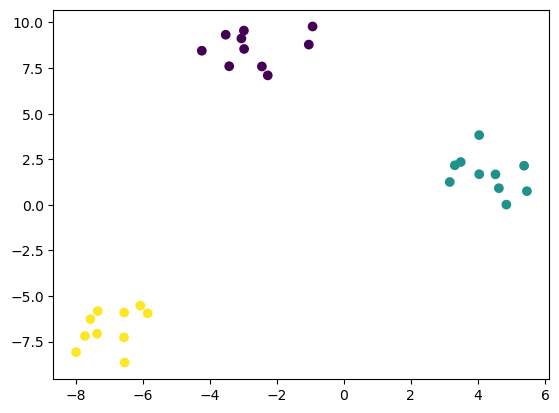

In [70]:
X, true_assignments = make_blobs(n_samples=30, centers=3, random_state=42)
plt.scatter(x=X[:, 0], y=X[:, 1], c=true_assignments);
print(X.shape)

### Initialize representatives by taking 3 data points

In [82]:
# initialize representatives

In [83]:
representatives = np.array([X[0], X[1], X[2]])

In [84]:
# Make a plot that shows where the representatives are. Include the data points.

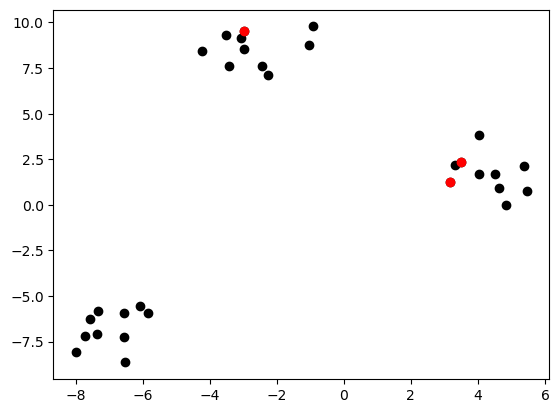

In [6]:
plt.scatter(x=X[:, 0], y=X[:, 1], c="black")
plt.scatter(x=representatives[:, 0], y=representatives[:, 1], c="red");

Let's define an auxiliary plotting function that we will use later.

In [85]:
def plot_representatives_and_assignments(X, point_assigments, representatives):
    plt.scatter(x=X[:, 0], y=X[:, 1], c=list(point_assigments))
    plt.scatter(x=representatives[:, 0], y=representatives[:, 1], c="red");
    plt.show()

### (i) Update the groups

We give details on each step of the algorithm. First, updating the groups.

- Given: representatives $z_1, ..., z_k$
- $\color{#EF5645}{\text{Goal for (i)}}$: Assign each data point $x_i$ to a group, i.e., choose $c_1, ..., c_N$
  - Assign each $x_i$ to its nearest representative.


In [88]:
X_per_cluster = [[], [], []] # Will become [G1, G2, G3]
assignments = []  # Will become: c1, ..., cN
print(representatives.shape)
# Update X and assignments

(3, 2)


30

In [36]:
X_per_cluster = [[], [], []] # Will become [G1, G2, G3]
assignments = []  # Will become: c1, ..., cN
print(X.shape)
for x in X:
    dists_to_representatives = np.linalg.norm(x - representatives, axis=1)
    c = np.argmin(dists_to_representatives)
    assignments.append(c)
    X_per_cluster[c].append(x)
np.mean(X_per_cluster[0], axis=0)

(30, 2)


array([-2.6860672 ,  8.58739003])

In [90]:
 # plot_representatives_and_assignments(X, assignments, representatives)

### (ii) Update the representatives

Next, we give details on how we update the representatives.

- Given the partition $G_1, . . . , G_k$
- $\color{#EF5645}{\text{Goal for (ii)}}$: Choose representatives $z_1, . . . , z_k$
  - Choose $z_j$ = mean of the points in group $j$.


In [106]:
# Update the representatives

In [92]:
representatives[0] = np.mean(X_per_cluster[0], axis=0)
representatives[1] = np.mean(X_per_cluster[1], axis=0)
representatives[2] = np.mean(X_per_cluster[2], axis=0)

In [108]:
# plot_representatives_and_assignments(X, assignments, representatives)

In [104]:
# Compute the objective: the average of squared distance from data points to their representative

# compute_objective_J(3, X_per_cluster, representatives)

In [105]:
def compute_objective_J(k, X_per_cluster, representatives):
    n_data = 0
    J = 0
    for j in range(k):
        dist_to_rep = np.linalg.norm(X_per_cluster[j] - representatives[j], axis=1)
        J = J + np.sum(dist_to_rep **2)
        n_data = n_data + len(X_per_cluster[j])
    return J / n_data 

compute_objective_J(3, X_per_cluster, representatives)

np.float64(26.544192273169124)

In [102]:
def k_means(X, k, show_plot):
    representatives = np.array(X[:k])
    distance_between_iterates = 10
    
    while distance_between_iterates > 0.1:
        current_representatives = np.copy(representatives)
        X_per_cluster = [[] for _ in range(k)]  # will become [G1, G2, G3]
        assignments = []  # will become [c1, ..., cN]

        for x in X:
            dists = np.linalg.norm(x - representatives, axis=1)
            c = np.argmin(dists)
            assignments.append(c)
            X_per_cluster[c].append(x)
        
        for j in range(k):
            representatives[j] = np.mean(X_per_cluster[j], axis=0)
        
        distance_between_iterates = np.linalg.norm(
            current_representatives - representatives)
        print(distance_between_iterates)
        print(compute_objective_J(k, X_per_cluster, representatives))
        if show_plot:
            plot_representatives_and_assignments(
                X, assignments, representatives)
            
    return representatives, assignments

9.094877096567991
19.297181437321917


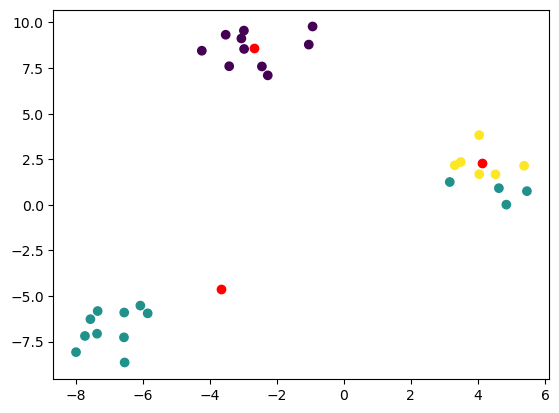

3.971132367385862
1.6006752020512967


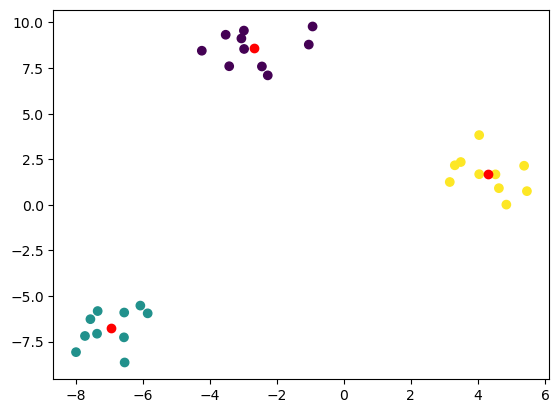

0.0
1.6006752020512967


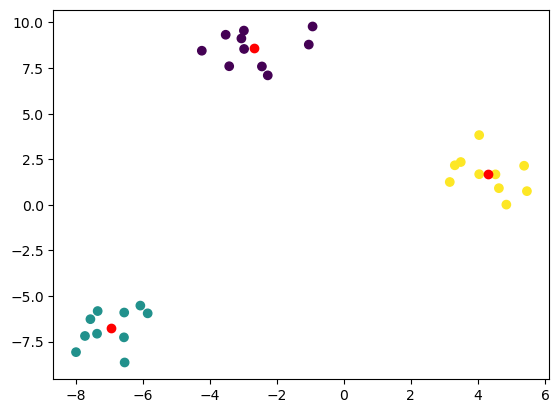

In [103]:
representatives, assignments = k_means(X, 3, True)

Congratulations! You've coded your first Machine Learning algorithm!

<center><img src="figs/04_otter.jpg" width=900 alt="default"/></center>

# Connectome Dataset: Use Clustering to Find Diseases

Consider a brain divided into 28 different areas. A connectome associated with this brain is a matrix $A$ such that $A_{ij}$ quantifies whether area $i$ and area $j$ tend to be activated together.

$\color{#EF5645}{\text{Question}}$: We have a dataset of 86 connectomes where some belong to healthy patients, and others to schizophrenic patients. We want to group the connectomes into two clusters.

<center><img src="figs/03_parcellation.png" width=400px alt="default"/></center>

<center>A brain divided into several areas.</center>

We use an auxiliary package, called geomstats, to import a connectome dataset. The 86 connectomes are in the `data` variable. We plot them.

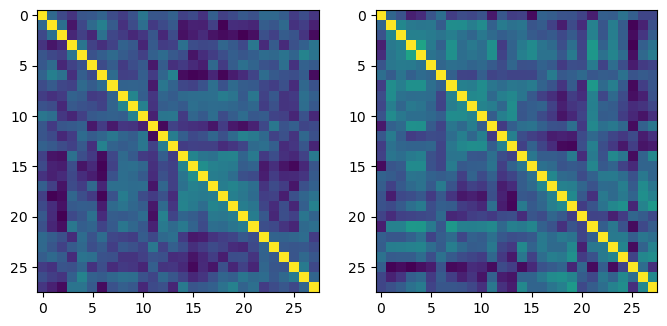

In [43]:
import geomstats.datasets.utils as data_utils
data, _, labels = data_utils.load_connectomes()
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(121); imgplot = ax.imshow(data[0])
ax = fig.add_subplot(122); imgplot = ax.imshow(data[1])

### Apply the K-means algorithm

First, convert every data point (connectome, i.e., matrix with 28 rows and 28 columns) into a vector (of size $28\times28=784$) using the function reshape. Then, we run our K-means function.

In [100]:
print(data.shape)
# Apply kmeans

(86, 28, 28)
(86, 784)


In [44]:
print(data.shape)
X_connectome = data.reshape((86, 28*28))
print(X_connectome.shape)
representatives, assignments = k_means(X_connectome, k=2, show_plot=False)

(86, 28, 28)
(86, 784)
4.470989061114848
0.32025319298058125
0.21898171830537327
0.2899034453771421
0.12839284615663107
0.13487371960131528
0.0


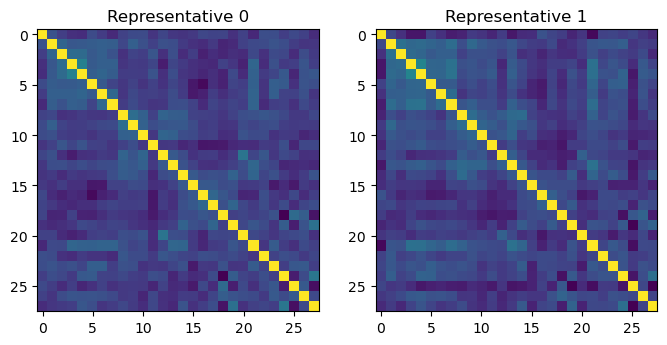

In [45]:
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(121); imgplot = ax.imshow(representatives[0].reshape(28, 28)); ax.set_title("Representative 0")
ax = fig.add_subplot(122); imgplot = ax.imshow(representatives[1].reshape(28, 28)); ax.set_title("Representative 1");

We have found the two groups of patients !

# Outline of Unit 04

  - **What is Machine Learning? How it is different from AI?**
  - **Clustering**
    - Understand the fundamentals behind clustering
    - K-means: Intuition and theory
    - K-means: Can you code it?
    - Connectome Dataset: Use clustering to find neurological diseases
  - **Linear regression**
    